In [1]:
import pandas as pd

df = pd.read_csv("samplesuperstore.csv")
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


DATASET SHAPE
(10194, 21)

FIRST 5 ROWS
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  US-2023-103800   1/3/2023   1/7/2023  Standard Class    DP-13000   
1       2  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
2       3  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
3       4  US-2023-112326   1/4/2023   1/8/2023  Standard Class    PO-19195   
4       5  US-2023-141817   1/5/2023  1/12/2023  Standard Class    MB-18085   

   Customer Name      Segment Country/Region          City  ... Postal Code  \
0  Darren Powers     Consumer  United States       Houston  ...       77095   
1  Phillina Ober  Home Office  United States    Naperville  ...       60540   
2  Phillina Ober  Home Office  United States    Naperville  ...       60540   
3  Phillina Ober  Home Office  United States    Naperville  ...       60540   
4     Mick Brown     Consumer  United States  Philadelphia  ...       19143   

    Region

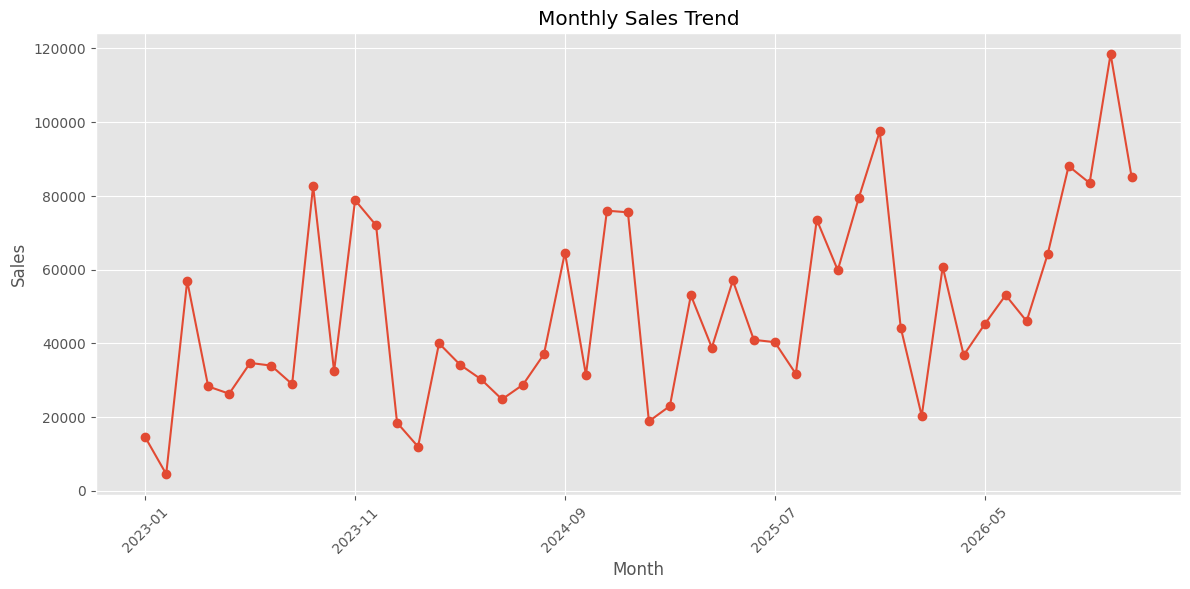

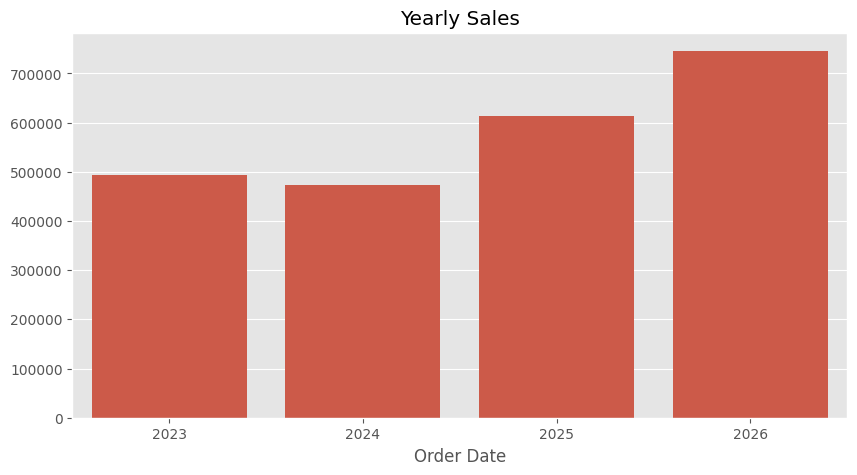

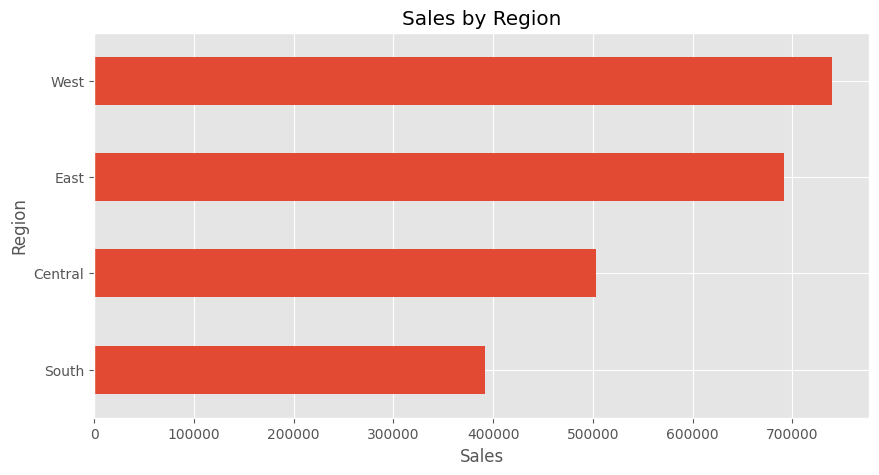

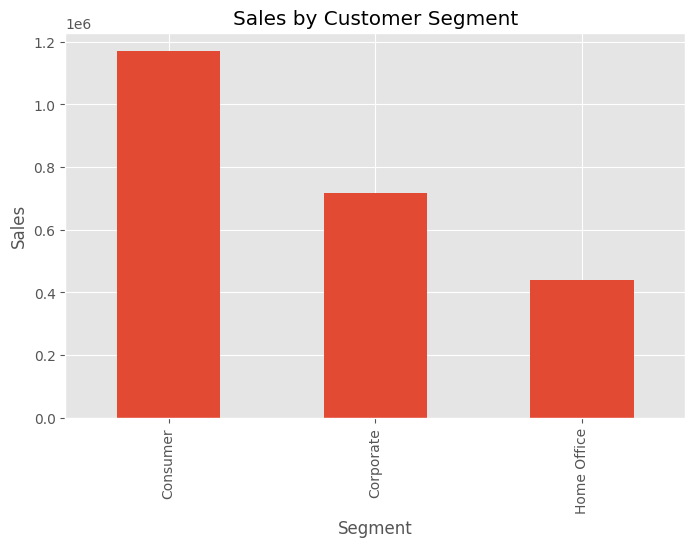

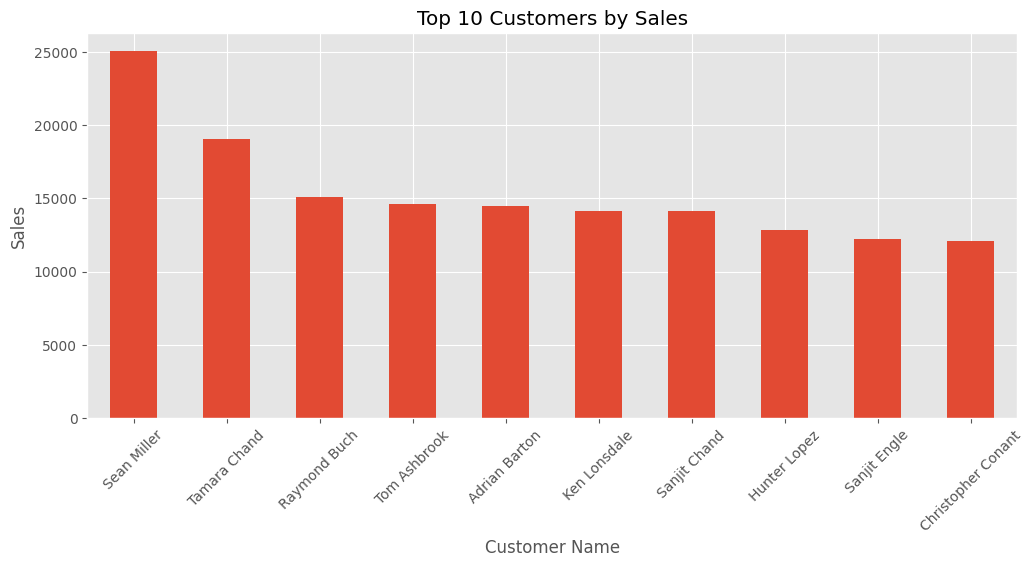

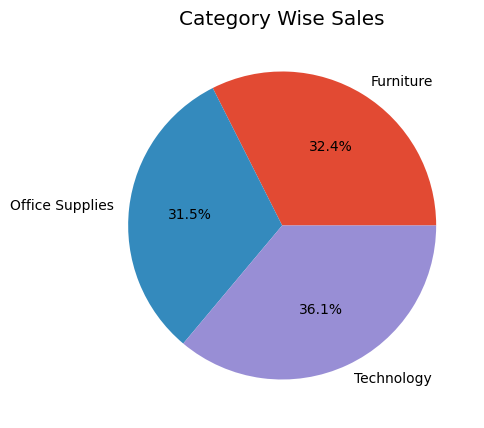

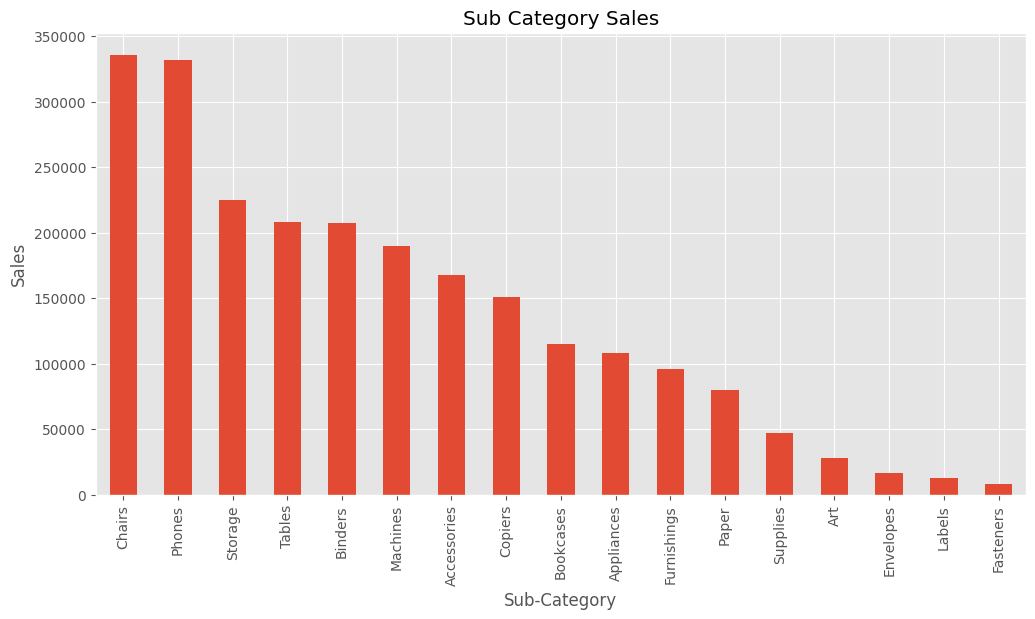

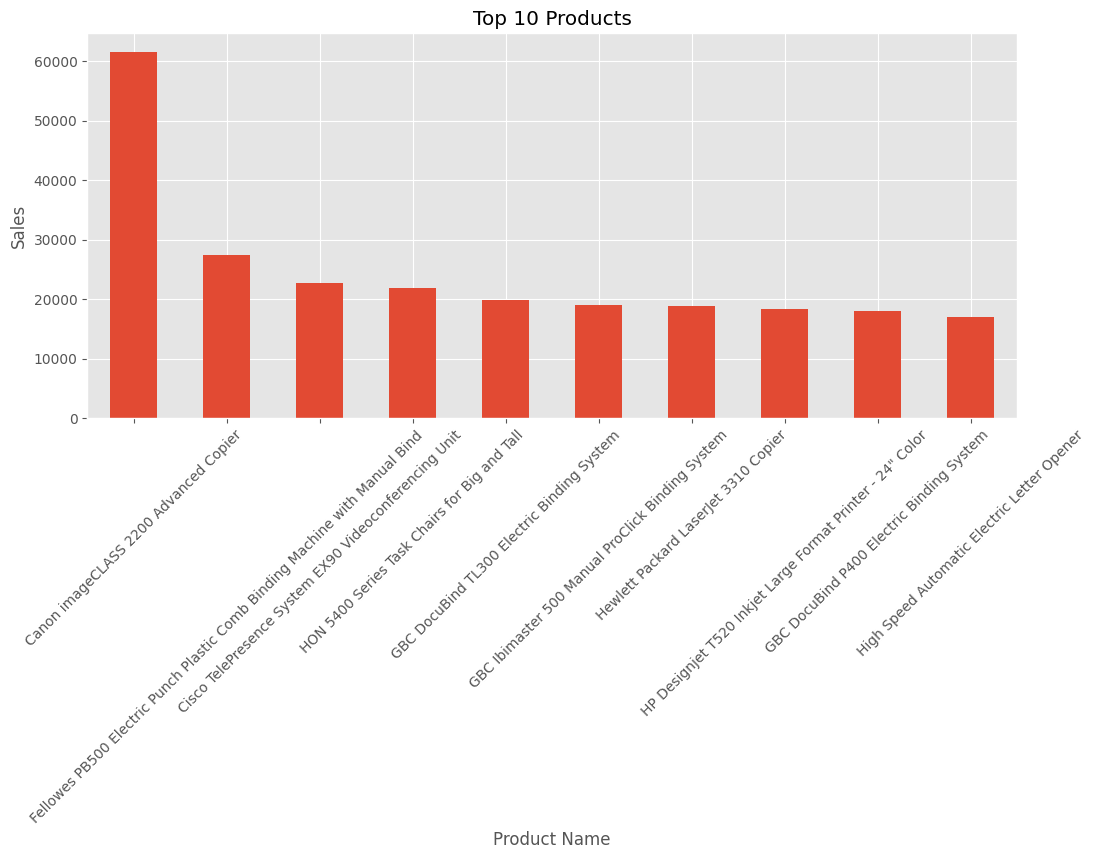

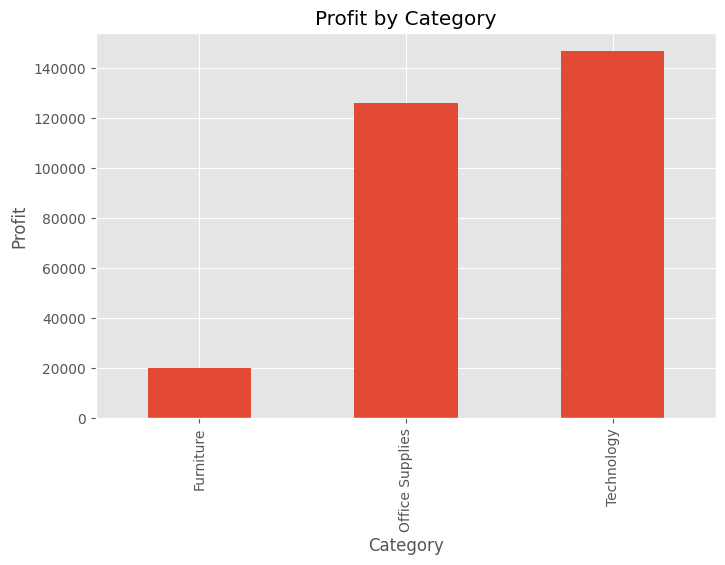

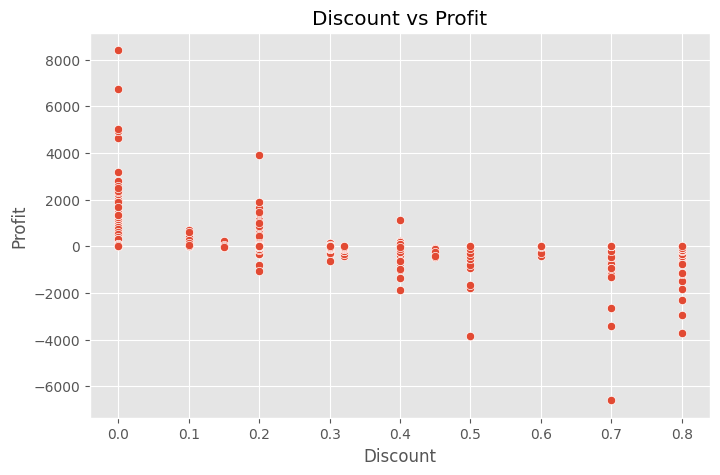

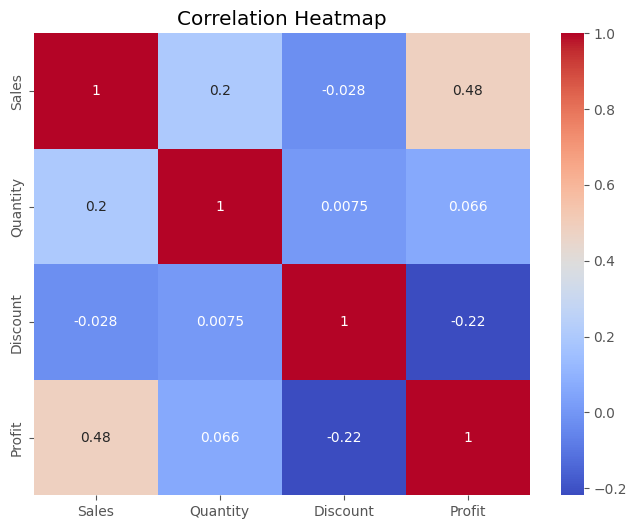

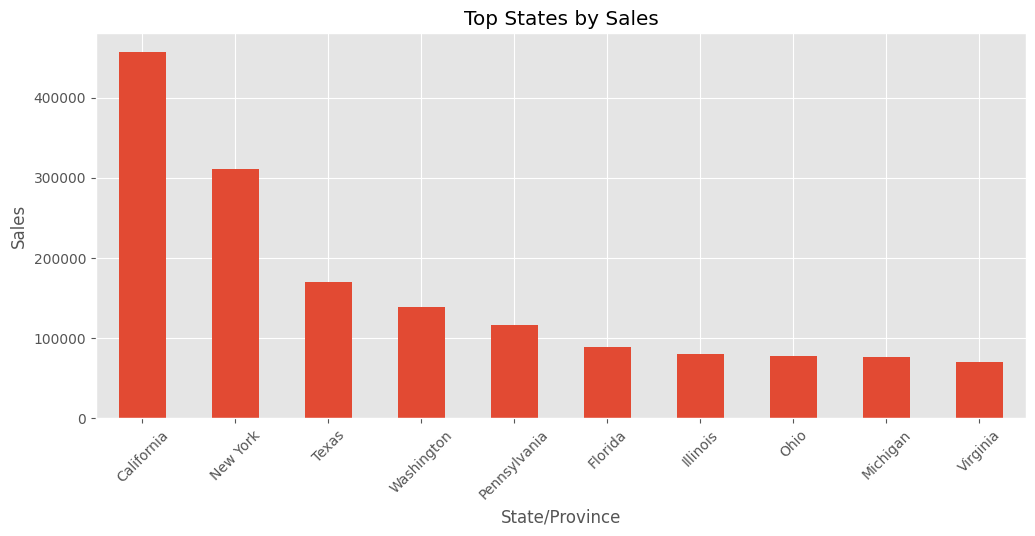

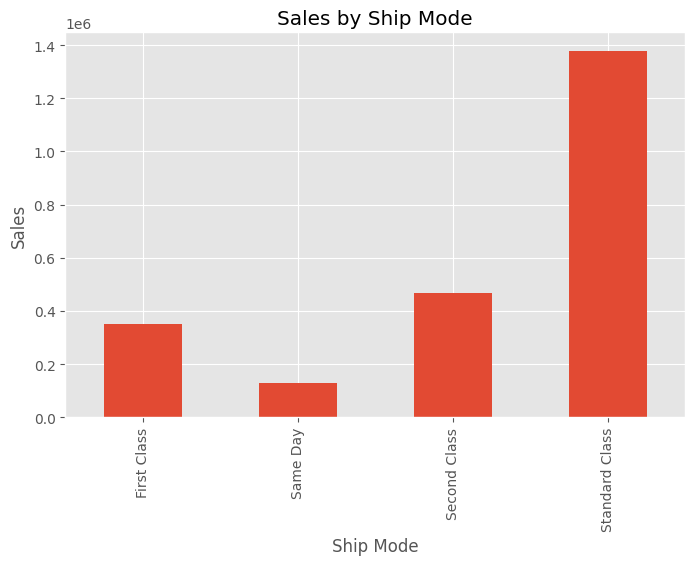

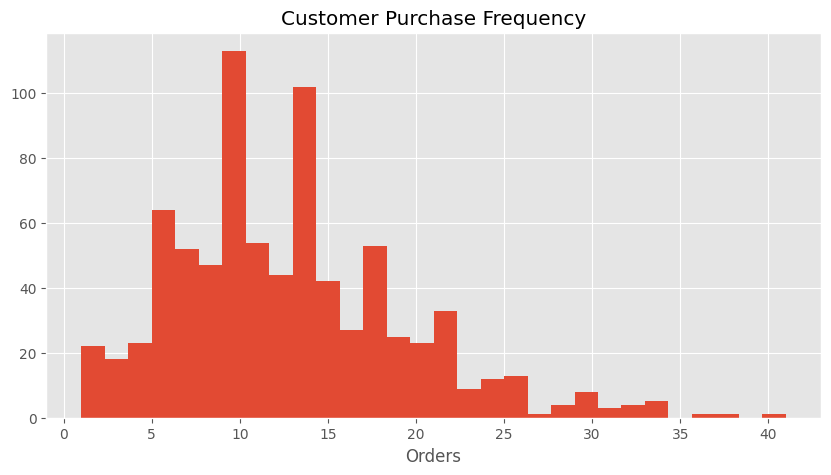


========== KEY INSIGHTS ==========

1. Highest Sales Category:
Technology

2. Highest Revenue Region:
West

3. Most Profitable Category:
Technology

4. Top Customer:
Sean Miller

5. Best Selling Product:
Canon imageCLASS 2200 Advanced Copier

========== RECOMMENDATIONS ==========

1. Focus marketing on top-performing regions.

2. Increase inventory for best-selling products.

3. Reward loyal customers through loyalty programs.

4. Review high-discount products that reduce profit.

5. Promote profitable product categories.

6. Improve sales in low-performing regions through targeted campaigns.

7. Optimize shipping methods to improve customer satisfaction.



In [3]:
# ==========================================
# RETAIL SALES EDA PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("samplesuperstore.csv", encoding='latin1')

print("="*50)
print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

# ==========================================
# DATA CLEANING
# ==========================================

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

df['Order Date'] = pd.to_datetime(df['Order Date'])

# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================

print("\nDESCRIPTIVE STATISTICS")
print(df[['Sales','Quantity','Discount','Profit']].describe())

print("\nMEAN SALES:", df['Sales'].mean())
print("MEDIAN SALES:", df['Sales'].median())
print("MODE SALES:", df['Sales'].mode()[0])
print("STD SALES:", df['Sales'].std())

# ==========================================
# TOTAL SALES AND PROFIT
# ==========================================

print("\nTOTAL SALES:", round(df['Sales'].sum(),2))
print("TOTAL PROFIT:", round(df['Profit'].sum(),2))

# ==========================================
# TIME SERIES ANALYSIS
# ==========================================

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# YEARLY SALES TREND
# ==========================================

yearly_sales = df.groupby(
    df['Order Date'].dt.year
)['Sales'].sum()

plt.figure(figsize=(10,5))
sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)
plt.title("Yearly Sales")
plt.show()

# ==========================================
# REGION ANALYSIS
# ==========================================

region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(10,5))
region_sales.plot(kind='barh')
plt.title("Sales by Region")
plt.xlabel("Sales")
plt.show()

# ==========================================
# SEGMENT ANALYSIS
# ==========================================

segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.ylabel("Sales")
plt.show()

# ==========================================
# TOP 10 CUSTOMERS
# ==========================================

top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# CATEGORY ANALYSIS
# ==========================================

category_sales = (
    df.groupby('Category')['Sales']
    .sum()
)

plt.figure(figsize=(8,5))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)
plt.title("Category Wise Sales")
plt.show()

# ==========================================
# SUB CATEGORY ANALYSIS
# ==========================================

sub_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sub_sales.plot(kind='bar')
plt.title("Sub Category Sales")
plt.ylabel("Sales")
plt.show()

# ==========================================
# TOP PRODUCTS
# ==========================================

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# PROFIT ANALYSIS
# ==========================================

profit_category = (
    df.groupby('Category')['Profit']
    .sum()
)

plt.figure(figsize=(8,5))
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

# ==========================================
# DISCOUNT VS PROFIT
# ==========================================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)
plt.title("Discount vs Profit")
plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# STATE ANALYSIS
# ==========================================

top_states = (
    df.groupby('State/Province')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
top_states.plot(kind='bar')
plt.title("Top States by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# SHIP MODE ANALYSIS
# ==========================================

ship_sales = (
    df.groupby('Ship Mode')['Sales']
    .sum()
)

plt.figure(figsize=(8,5))
ship_sales.plot(kind='bar')
plt.title("Sales by Ship Mode")
plt.ylabel("Sales")
plt.show()

# ==========================================
# CUSTOMER PURCHASE BEHAVIOR
# ==========================================

customer_orders = (
    df.groupby('Customer ID')
    .size()
)

plt.figure(figsize=(10,5))
customer_orders.hist(bins=30)
plt.title("Customer Purchase Frequency")
plt.xlabel("Orders")
plt.show()

# ==========================================
# KEY INSIGHTS
# ==========================================

print("\n========== KEY INSIGHTS ==========")

print("\n1. Highest Sales Category:")
print(category_sales.idxmax())

print("\n2. Highest Revenue Region:")
print(region_sales.idxmax())

print("\n3. Most Profitable Category:")
print(profit_category.idxmax())

print("\n4. Top Customer:")
print(top_customers.idxmax())

print("\n5. Best Selling Product:")
print(top_products.idxmax())

# ==========================================
# RECOMMENDATIONS
# ==========================================

print("\n========== RECOMMENDATIONS ==========")

print("""
1. Focus marketing on top-performing regions.

2. Increase inventory for best-selling products.

3. Reward loyal customers through loyalty programs.

4. Review high-discount products that reduce profit.

5. Promote profitable product categories.

6. Improve sales in low-performing regions through targeted campaigns.

7. Optimize shipping methods to improve customer satisfaction.
""")